[link](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)

# Data

The Diabetes prediction dataset is a collection of medical and demographic data from patients, along with their diabetes status (positive or negative). The data includes features such as age, gender, body mass index (BMI), hypertension, heart disease, smoking history, HbA1c level, and blood glucose level. This dataset can be used to build machine learning models to predict diabetes in patients based on their medical history and demographic information. This can be useful for healthcare professionals in identifying patients who may be at risk of developing diabetes and in developing personalized treatment plans. Additionally, the dataset can be used by researchers to explore the relationships between various medical and demographic factors and the likelihood of developing diabetes.

고혈압 여부 (Hypertension)

HbA1c_level 혈액 속 당이 얼마나 높을까? 나타내는 지표

blood_glucose_level 혈당 레벨

# Import

In [35]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve


# Data

In [36]:
df = pd.read_csv("../../../../delete/diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [37]:
df.diabetes.value_counts()

0    91500
1     8500
Name: diabetes, dtype: int64

In [38]:
df.gender.value_counts()

Female    58552
Male      41430
Other        18
Name: gender, dtype: int64

In [39]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

In [40]:
df['smoking_history'] = df['smoking_history'].map({'No Info	': 0, 'never': 1, 'former': 2, 'current': 3, 'not current': 4, 'ever': 5})

In [41]:
df['diabetes'].value_counts()

0    91500
1     8500
Name: diabetes, dtype: int64

# EDA

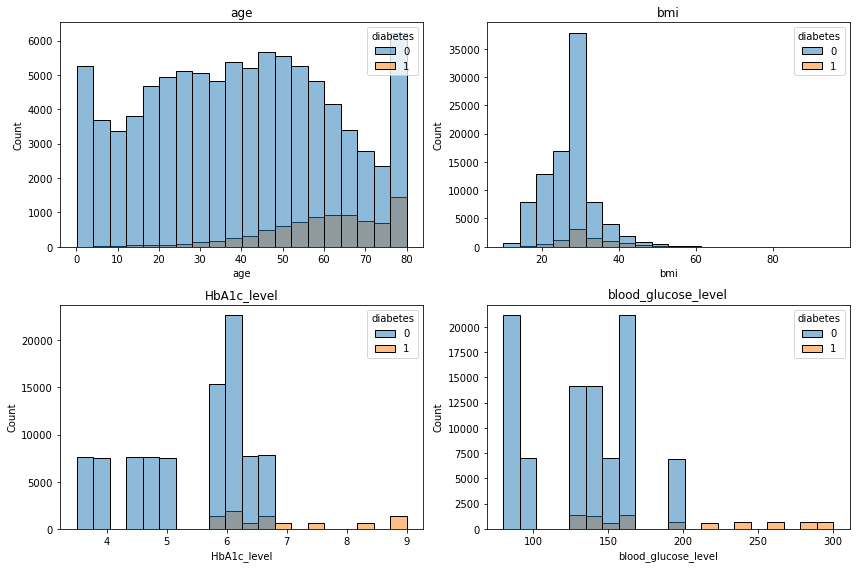

In [42]:
cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    sns.histplot(data=df, x=col, hue='diabetes', bins=20, ax=ax)
    ax.set_title(col)

plt.tight_layout();

| HbA1c (%) | 의미                   |
| --------- | -------------------- |
| < 5.7     | 정상                   |
| 5.7 ~ 6.4 | 당뇨 전단계 (Prediabetes) |
| ≥ 6.5     | 당뇨병                  |


- 당뇨가 있을때
    - 나이가 많을수록
    - bmi는 상관없어보이는..?
    - HbA1c 가 높을수록
    - 혈당은 일정 기준 넘어갈수록
- 당뇨가 있는 경향이 있다.

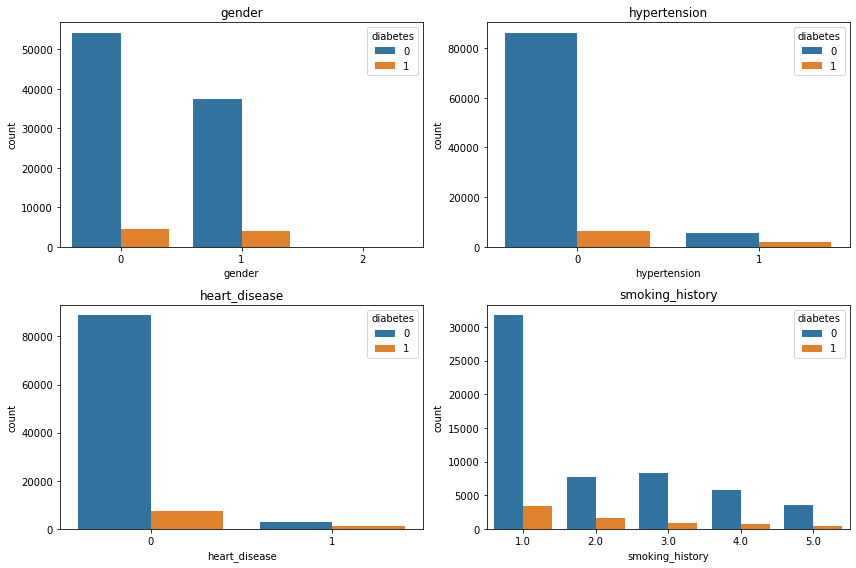

In [43]:
cols = ['gender', 'hypertension', 'heart_disease', 'smoking_history']

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    sns.countplot(data=df, x=col, hue='diabetes', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x')

plt.tight_layout();

In [44]:
df.diabetes.value_counts()

0    91500
1     8500
Name: diabetes, dtype: int64

- 당뇨 유무 차이가 너무 커서 normalized 해보았다.

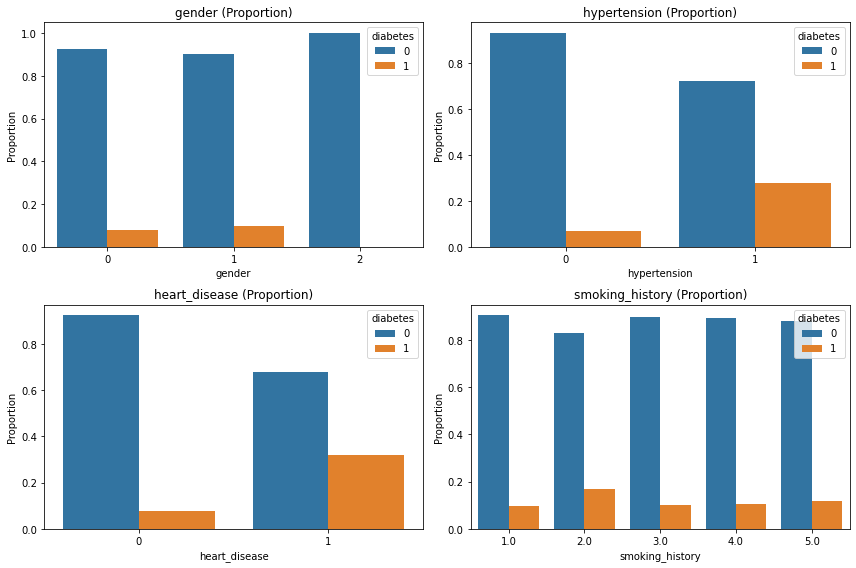

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    
    prop_df = (
        df.groupby(col)['diabetes']
        .value_counts(normalize=True)
        .rename('proportion')
        .reset_index()
    )
    
    sns.barplot(data=prop_df, x=col, y='proportion', hue='diabetes', ax=ax)
    ax.set_title(f'{col} (Proportion)')
    ax.set_ylabel('Proportion')

plt.tight_layout();

- 그래도 판단이 어려워서 당뇨 있는 환자들만 봤다.

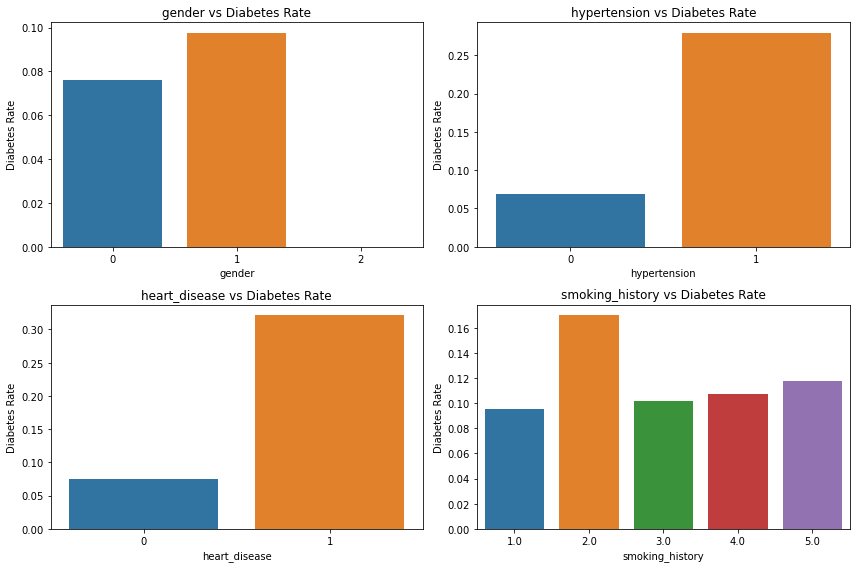

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    
    prop_df = df.groupby(col)['diabetes'].mean().reset_index()
    
    sns.barplot(data=prop_df, x=col, y='diabetes', ax=ax)
    ax.set_title(f'{col} vs Diabetes Rate')
    ax.set_ylabel('Diabetes Rate')

plt.tight_layout();

- 남성이 당뇨 비율이 높다.
- 고혈압이 있는 사람이 당뇨 비율이 높다.
- 심장 질환 있는 사람이 당뇨 비율이 높다.
- 흡연은 영향이 없어보인다.

# Logistic Regression

In [47]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,1.0,25.19,6.6,140,0
1,0,54.0,0,0,NaN,27.32,6.6,80,0
2,1,28.0,0,0,1.0,27.32,5.7,158,0
3,0,36.0,0,0,3.0,23.45,5.0,155,0
4,1,76.0,1,1,3.0,20.14,4.8,155,0


- 관련 없어 보이던 흡연 여부와 나이는 제거

In [48]:
X = df[['gender','age','hypertension','heart_disease','HbA1c_level','blood_glucose_level']]
y = df['diabetes']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [51]:
y_pred = model.predict(X_test)

In [52]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),2))

Accuracy: 0.96


In [53]:
y_prob = model.predict_proba(X_test)[:,1]

In [54]:
print("ROC AUC:", round(roc_auc_score(y_test, y_prob),2))

ROC AUC: 0.95


In [55]:
coef = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

In [56]:
print(round(coef,2))

              Variable  Coefficient  Odds Ratio
0               gender         0.22        1.25
1                  age         0.04        1.05
2         hypertension         0.94        2.57
3        heart_disease         0.75        2.11
4          HbA1c_level         2.34       10.39
5  blood_glucose_level         0.03        1.03


- 고혈압hypertension 이나 심장질환 heart_disease이 있으면 위험 약 2배 증가
- 특히, HbA1c 1 증가시 위험 10배 증가

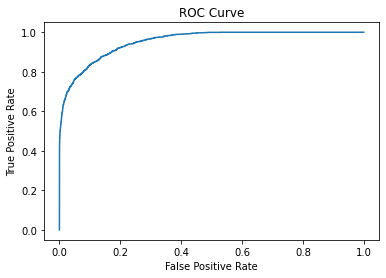

In [57]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve");

- 당뇨를 피하려면 고혈압 환자, 심장 질환 환자는 조심해야 함.
-  HbA1c는 영향이 너무 커서 논의가 필요.
    - 표준화하고 시도했을때는 더 큰 odds ratio가 나왔음.